# Working with Real-World Data and Non-Linear Patterns

In [1]:
import torch
print(torch.__version__)

2.8.0


In [2]:
import torch.nn as nn
import torch.optim as optim

# Setting up seed ensures results are reproducible and consistent across runs
torch.manual_seed(25)

## Step 1: Data Preparation

We'll load real-world housing data from a CSV file and prepare it for training.

In [3]:
# Load real-world housing data from CSV file
import pandas as pd

# Read the dataset
df = pd.read_csv('/Users/akshay/Work/data/housing_data/train.csv')
# Filter data to reasonable house sizes (500-5000 sqft)
df = df[(df['SQUARE_FT'] <= 5000) & (df['SQUARE_FT'] >= 500)]
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [4]:
# Convert pandas DataFrame columns to PyTorch tensors
# reshape(-1, 1) converts 1D array to 2D column vector [N, 1] required by PyTorch
size = torch.tensor(df['SQUARE_FT'].values.reshape(-1, 1), dtype=torch.float32)
price = torch.tensor(df['TARGET(PRICE_IN_LACS)'].values.reshape(-1, 1), dtype=torch.float32)

### Visualizing the Data

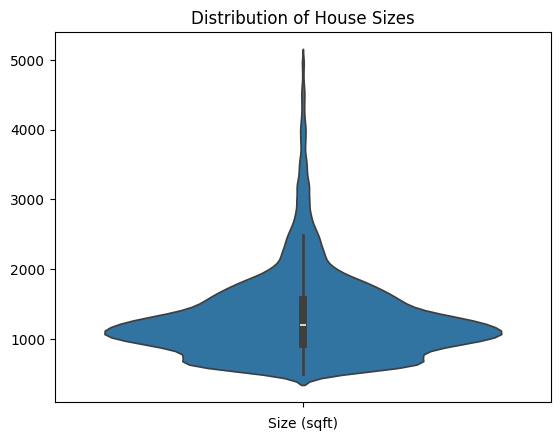

In [5]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Violin plot showing distribution of house sizes
sns.violinplot(y=size.flatten().numpy())
plt.xlabel('Size (sqft)')
plt.title('Distribution of House Sizes')
plt.show()

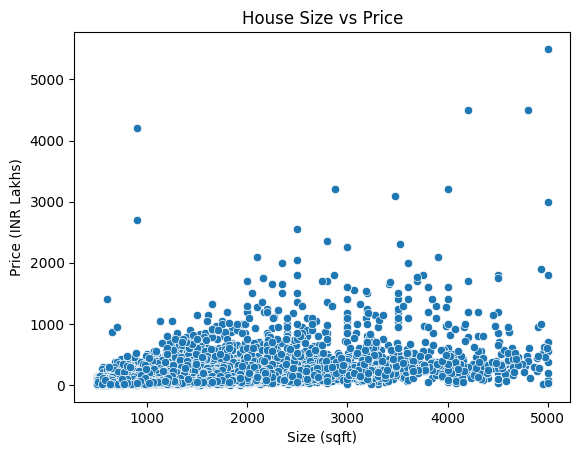

In [6]:
# Scatter plot to visualize the relationship between size and price
sns.scatterplot(x=size.flatten().numpy(), y=price.flatten().numpy())
plt.xlabel('Size (sqft)')
plt.ylabel('Price (INR Lakhs)')
plt.title('House Size vs Price')
plt.show()

### Normalizing the Data

In [7]:
# Standardization: (x - mean) / std
# This transforms data to have mean=0 and standard deviation=1
size_norm = (size - size.mean()) / size.std()
price_norm = (price - price.mean()) / price.std()

Visualize the normalized data to see how standardization affects the distribution.


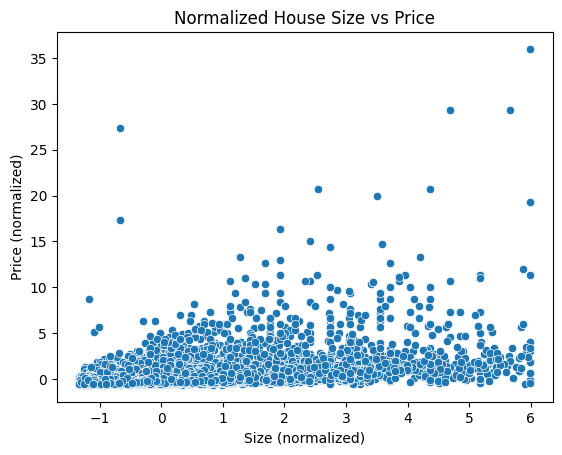

In [8]:
# Scatter plot of normalized data
sns.scatterplot(x=size_norm.flatten().numpy(), y=price_norm.flatten().numpy())
plt.xlabel('Size (normalized)')
plt.ylabel('Price (normalized)')
plt.title('Normalized House Size vs Price')
plt.show()

## Step 2: Define the Neural Network Model

For non-linear relationships, we'll use a multi-layer network with an activation function (ReLU) between layers.

We'll use `nn.Sequential` with multiple layers:
- First `nn.Linear(1, 3)`: 1 input → 3 hidden neurons
- `nn.ReLU()`: Activation function for non-linearity. This non-linearity allows model to learn curves rather than just a straight line.
- Second `nn.Linear(3, 1)`: 3 hidden neurons → 1 output
- There are three layers
    - input layer with a single neuron.
    - hidden layer with 3 neurons.
    - output layer with a single neuron.
- This architecture can learn non-linear patterns in the data.

In [9]:
# Create a neural network with hidden layer for non-linear patterns
model = nn.Sequential(
    nn.Linear(1, 3),  # Input layer: 1 feature → 3 hidden neurons
    nn.ReLU(),        # Activation function: introduces non-linearity
    nn.Linear(3, 1)   # Output layer: 3 hidden neurons → 1 output
)
model

Sequential(
  (0): Linear(in_features=1, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
)

## Step 3: Define Loss Function and Optimizer

- **Loss Function**: Measures the difference between predictions and actual values
- **Optimizer**: Updates model parameters (weights and biases) to minimize the loss
    - **Learning Rate**: Controls how much the optimizer adjusts parameters in each step

In [10]:
loss_fn = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD(model.parameters(), lr=0.001)  # Stochastic Gradient Descent Optimizer

## Step 4: Training Loop

The training loop repeats the following steps for multiple epochs:
1. Reset gradients: Clear gradients from previous epochs
2. Forward pass: Make predictions
3. Calculate loss: Compare predictions with targets
4. Backward pass: Compute gradients
5. Update parameters: Adjust weights and biases

In [11]:
max_epochs = 5000

for epoch in range(max_epochs):
    # Reset gradients to zero (gradients accumulate by default)
    optimizer.zero_grad()

    # Forward pass: Make predictions
    # Note: Using unnormalized data - normalization would improve training
    predicted_price = model(size_norm)
    
    # Calculate loss: Compare predictions with actual prices
    loss = loss_fn(predicted_price, price_norm)

    # Backward pass: Compute gradients
    loss.backward()

    # Update model parameters using computed gradients
    optimizer.step()

    # Print progress every 500 epochs
    if (epoch+1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{max_epochs}] | Loss: {loss.item():.4f}')

Epoch [500/5000] | Loss: 0.8980
Epoch [1000/5000] | Loss: 0.8614
Epoch [1500/5000] | Loss: 0.8348
Epoch [2000/5000] | Loss: 0.8164
Epoch [2500/5000] | Loss: 0.8036
Epoch [3000/5000] | Loss: 0.7946
Epoch [3500/5000] | Loss: 0.7883
Epoch [4000/5000] | Loss: 0.7837
Epoch [4500/5000] | Loss: 0.7803
Epoch [5000/5000] | Loss: 0.7776


### Inspecting Learned Parameters

After training, check the learned weight and bias values.

In [12]:
layer_0 = model[0]
print(f'Weights: {layer_0.weight.data}, Bias: {layer_0.bias.data}')

Weights: tensor([[ 0.9127],
        [-0.5914],
        [-0.8362]]), Bias: tensor([ 0.6009, -0.2234, -0.4185])


## Step 5: Making Predictions

Use the trained model to predict prices for new house sizes. Use `torch.no_grad()` to disable gradient computation during inference (saves memory and computation).

In [24]:
# Create input tensor for prediction
# Note: Input should match training data scale (unnormalized in this case)
house_size = torch.tensor([[4000.0]], dtype=torch.float32)

# normalize the house size
house_size_norm = (house_size - size_norm.mean()) / size.std()
house_size_norm


tensor([[6.5084]])

In [ ]:
# Make prediction without computing gradients (faster and uses less memory)
with torch.no_grad():
    predicted_price = model(house_size)
    predicted_price_actual = predicted_price * price.std() + price.mean()
    
    # Display prediction
    print(f'Predicted price for a house of size {house_size.item()} is ${predicted_price_actual.item():.2f}')

Predicted price for a house of size 4000.0 is $286736.12
